In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import seaborn as sns
import scipy
from scipy import stats
import os
import pickle

In [40]:
data_labels = []
path='/Volumes/data_ssd2/Rojas_Lab/data' 
expt_id = '/251212_TEM' # the experiment title
with open(path+expt_id+expt_id+'_thicknesses.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data_labels.append(row) # Data should be saved in UTF-8 format
        line_count += 1
sample_ID={'ponA LB (CTRL)':r'$\Delta ponA$ LB', 'ponA tun':r'$\Delta ponA$ Tun'}
types={'Horizontal thickness (pixels)':'Horizontal', 'Longitudinal thickness (pixels)':'Longitudinal'}
col=['Condition','Thickness','Type']
df=pd.DataFrame(columns=col)
sample_inds=[sample_ID[val] for val in data_labels[0]]
for row in data_labels[2:]:
    for ind in range(len(row)):
        if row[ind]!='':
            temp_df=pd.DataFrame(columns=col,data=[[sample_inds[ind],float(row[ind]),types[data_labels[1][ind]]]])
            df=pd.concat([df,temp_df])

In [41]:
data_labels = []
path='/Volumes/data_ssd2/Rojas_Lab/data' 
expt_id = '/250519_TEM' # the experiment title
with open(path+expt_id+expt_id+'_thicknesses_2sample.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data_labels.append(row) # Data should be saved in UTF-8 format
        line_count += 1
sample_ID={'Sample 1':'WT LB', 'Sample 2':r'WT Tun'}
types={'Horizontal thickness (pixels)':'Horizontal', 'Longitudinal thickness (pixels)':'Longitudinal'}
col=['Condition','Thickness','Type']
df1=pd.DataFrame(columns=col)
sample_inds=[sample_ID[val] for val in data_labels[0]]
for row in data_labels[2:]:
    for ind in range(len(row)):
        if row[ind]!='':
            temp_df=pd.DataFrame(columns=col,data=[[sample_inds[ind],float(row[ind]),types[data_labels[1][ind]]]])
            df1=pd.concat([df1,temp_df])

In [42]:
scale=500.0/764.0
df=pd.concat([df1,df])
df['Thickness (nm)']=df['Thickness']*scale

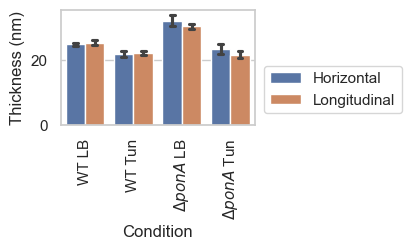

In [43]:
fig=plt.figure(figsize=[2.5,1.5])
sns.set(font_scale=1.0)
sns.set_style('whitegrid')
colors=sns.color_palette()
sns.barplot(data=df,x='Condition',y='Thickness (nm)',hue='Type',capsize=0.2,errorbar='se')
plt.legend(loc=[1.05,0.1])
plt.xticks(rotation=90)
plt.ylabel('Thickness (nm)')
if not os.path.exists('./outputs/'+expt_id):
    os.mkdir('./outputs/'+expt_id)

In [44]:
types=[r'$\Delta ponA$','WT']
conds=['+', '-']
df['Celltype']=[types['WT' in cond] for cond in df.Condition]
df['Tunicamycin']=[conds['LB' in cond] for cond in df.Condition]

In [45]:
df.sample(10)

,Condition,Thickness,Type,Thickness (nm),Celltype,Tunicamycin
0,WT LB,38.810,Longitudinal,25.399215,WT,-
0,$\Delta ponA$ LB,55.714,Horizontal,36.462042,$\Delta ponA$,-
0,$\Delta ponA$ Tun,32.582,Horizontal,21.323298,$\Delta ponA$,+
0,WT LB,34.884,Longitudinal,22.829843,WT,-
0,WT LB,38.161,Longitudinal,24.974476,WT,-
0,WT LB,33.838,Horizontal,22.145288,WT,-
0,WT LB,37.431,Longitudinal,24.496728,WT,-
0,WT Tun,32.515,Horizontal,21.279450,WT,+
0,WT LB,39.093,Horizontal,25.584424,WT,-
0,$\Delta ponA$ LB,49.644,Longitudinal,32.489529,$\Delta ponA$,-


In [46]:
df.groupby(['Condition', 'Type']).mean()

/var/folders/7d/cgvlmd010jb53nbnkbjsc8r80000gp/T/ipykernel_12335/806007384.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df.groupby(['Condition', 'Type']).mean()


Thickness  Thickness (nm)
Condition         Type                                   
$\Delta ponA$ LB  Horizontal    49.384643       32.319792
                  Longitudinal  46.589818       30.490719
$\Delta ponA$ Tun Horizontal    36.065895       23.603334
                  Longitudinal  33.274480       21.776492
WT LB             Horizontal    38.087800       24.926571
                  Longitudinal  38.912500       25.466296
WT Tun            Horizontal    33.547423       21.955120
                  Longitudinal  33.989594       22.244499

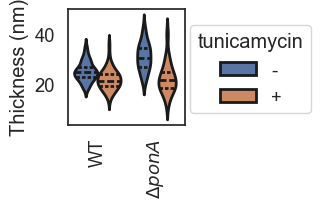

In [64]:
fig=plt.figure(figsize=[1.5,1.5])
sns.set(font_scale=1.2)
sns.set_style('white')
colors=sns.color_palette()
# sns.barplot(data=df,x='Celltype',y='Thickness (nm)',hue='Tunicamycin',capsize=0.2,errorbar='se')
# sns.boxplot(data=df,x='Celltype',y='Thickness (nm)',hue='Tunicamycin',dodge=True)
sns.violinplot(data=df,x='Celltype',y='Thickness (nm)',hue='Tunicamycin',inner='quart',linewidth=2,linecolor='k')
plt.legend(loc=[1.05,0.1],title='tunicamycin')
plt.xticks(rotation=90)
plt.ylabel('Thickness (nm)')
plt.xlabel('')
if not os.path.exists('./outputs/'+expt_id):
    os.mkdir('./outputs/'+expt_id)
fig.savefig('./outputs/'+expt_id+expt_id+'thickness_comp.pdf',bbox_inches='tight')

In [71]:
for ctype in df.Celltype.unique():
    print(ctype, scipy.stats.ttest_ind(df[(df.Tunicamycin=='-')*(df.Celltype==ctype)]['Thickness'], df[(df.Tunicamycin=='+')*(df.Celltype==ctype)]['Thickness']))

WT Ttest_indResult(statistic=4.431202560191496, pvalue=2.0360620423518748e-05)
$\Delta ponA$ Ttest_indResult(statistic=7.041375573105131, pvalue=3.828913944671892e-10)


Okay, so we now are going to find the relative change for each cell type and will produce errors using bootstrap analysis

In [49]:
temp1=np.asarray(df[df.Condition=='WT LB']['Thickness (nm)'])
temp2=np.asarray(df[df.Condition=='WT Tun']['Thickness (nm)'])
temp3=np.asarray(df[df.Condition==r'$\Delta ponA$ LB']['Thickness (nm)'])
temp4=np.asarray(df[df.Condition==r'$\Delta ponA$ Tun']['Thickness (nm)'])
cols=['Celltype', 'percentage decrease']
df1=pd.DataFrame(columns=cols)
difs=[]
for i0 in range(1000):
    xv1=np.random.choice(temp1, size=100,replace=True)
    xv2=np.random.choice(temp2, size=100,replace=True)
    xv3=np.random.choice(temp3, size=100,replace=True)
    xv4=np.random.choice(temp4, size=100,replace=True)

    temp_out1=100.0*(1.0-np.mean(xv2)/np.mean(xv1))
    temp_out2=100.0*(1.0-np.mean(xv4)/np.mean(xv3))
    temp_df1=pd.DataFrame(columns=cols,data=[['WT',temp_out1],[r'$\Delta ponA$', temp_out2]])
    df1=pd.concat([df1,temp_df1])
    difs.append(temp_out2-temp_out1)

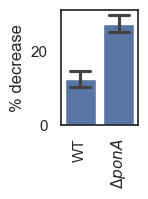

In [59]:
fig=plt.figure(figsize=[1.0,1.5])
sns.set(font_scale=1.0)
sns.set_style('white')
sns.barplot(data=df1,x='Celltype',y='percentage decrease',capsize=0.5,errorbar='sd')
# sns.violinplot(data=df1,x='Celltype',y='percentage decrease',inner=None)
plt.xlabel('')
plt.xticks(rotation=90)
plt.ylabel('% decrease')
fig.savefig('./outputs/251212_TEM/percentage_decrease.pdf',bbox_inches='tight')
plt.show()

To calculate significance, we will now perform a one-sided t-test on the bootstrapped differences.

In [12]:
t_stat=np.mean(difs)/np.std(difs)
print('t_statistic: ', t_stat)

t_statistic:  4.682802885738288


Now, let's visualize the distribution of t-statistics for our bootstrapped samples and see what percentile lies below zero.

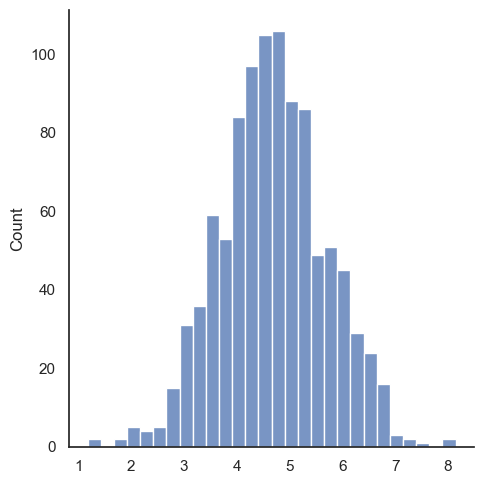

In [24]:
sns.displot(difs/np.std(difs))

In [18]:
perc=np.percentile(difs/np.std(difs),2.5)
print('2.5th percentile: ', perc)

2.5th percentile:  2.767661413064887


In [21]:
print('Percentage of T-values below zero: ', 100.0*np.sum(difs/np.std(difs)<0)/len(difs)*1.0)

Percentage of T-values below zero:  0.0


Since this is less than p/2 (p=5%), the difference is therefore significant.